In [2]:
# PHASE 1: DATA CLEANING & EDA


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("traffic.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 226278
Number of columns: 9


In [5]:
df.shape

(226278, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


In [7]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [8]:
df['date'].dtype

dtype('<M8[ns]')

In [9]:
df.describe(include='all')

,event,date,country,city,artist,album,track,isrc,linkid
count,226278,226278,226267,226267,226241,226273,226273,219157,226278
unique,3,NaN,211,11993,2419,3254,3562,709,3839
top,pageview,NaN,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
freq,142015,NaN,47334,22791,40841,40841,40841,40841,40841
mean,NaN,2021-08-21 21:04:31.768355584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,2021-08-19 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2021-08-20 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2021-08-22 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2021-08-24 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,2021-08-25 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.describe(include='object')

,event,country,city,artist,album,track,isrc,linkid
count,226278,226267,226267,226241,226273,226273,219157,226278
unique,3,211,11993,2419,3254,3562,709,3839
top,pageview,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
freq,142015,47334,22791,40841,40841,40841,40841,40841


In [11]:
missing_values = df.isnull().sum()

print(missing_values)

event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64


In [12]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': missing_percentage
})

missing_summary

,Missing Values,Missing Percentage
event,0,0.000000
date,0,0.000000
country,11,0.004861
city,11,0.004861
artist,37,0.016352
album,5,0.002210
track,5,0.002210
isrc,7121,3.147014
linkid,0,0.000000


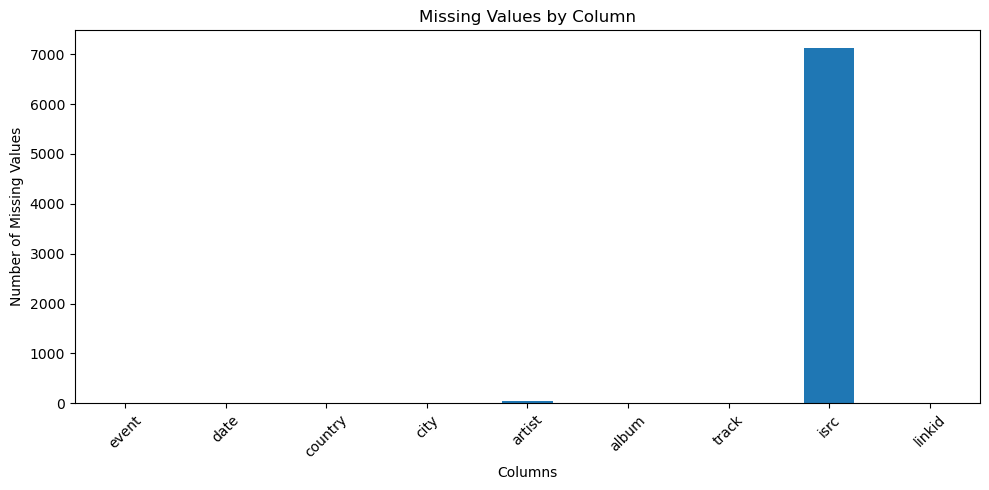

In [13]:
plt.figure(figsize=(10, 5))

missing_summary['Missing Values'].plot(kind='bar')

plt.title('Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 103711


In [16]:
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Duplicate percentage:", round(duplicate_percentage, 2), "%")

Duplicate percentage: 45.83 %


In [17]:
df = df.drop_duplicates().reset_index(drop=True)

In [18]:
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (122567, 9)


In [19]:
unique_values = df.nunique()

print(unique_values)

event          3
date           7
country      211
city       11993
artist      2419
album       3254
track       3562
isrc         709
linkid      3839
dtype: int64


In [20]:
summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str).values,
    'Unique Values': df.nunique().values,
    'Missing Values': df.isnull().sum().values
})

summary

,Column,Data Type,Unique Values,Missing Values
0,event,object,3,0
1,date,datetime64[ns],7,0
2,country,object,211,5
3,city,object,11993,5
4,artist,object,2419,28
5,album,object,3254,4
6,track,object,3562,4
7,isrc,object,709,6306
8,linkid,object,3839,0


In [21]:
event_counts = df['event'].value_counts()

print(event_counts)

event
pageview    73360
click       32499
preview     16708
Name: count, dtype: int64


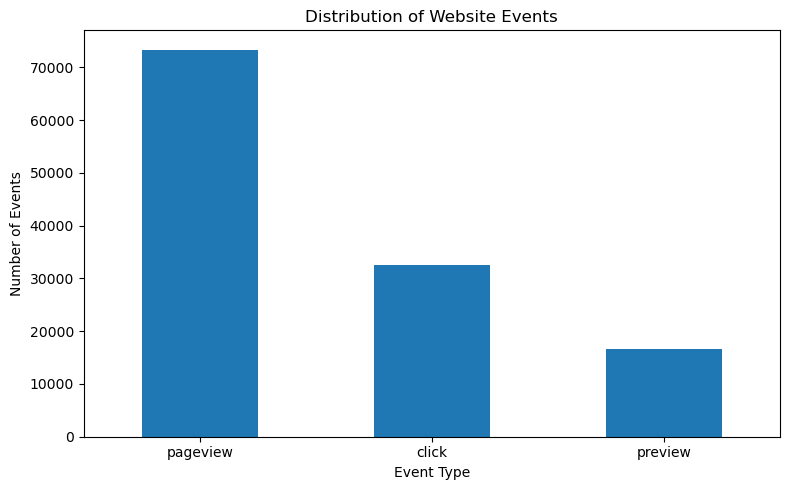

In [22]:
plt.figure(figsize=(8, 5))

event_counts.plot(kind='bar')

plt.title('Distribution of Website Events')
plt.xlabel('Event Type')
plt.ylabel('Number of Events')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
print("Minimum date:", df['date'].min())
print("Maximum date:", df['date'].max())

Minimum date: 2021-08-19 00:00:00
Maximum date: 2021-08-25 00:00:00


In [24]:
daily_events = df.groupby('date').size()

daily_events

date
2021-08-19    21156
2021-08-20    18536
2021-08-21    16701
2021-08-22    16927
2021-08-23    16415
2021-08-24    16291
2021-08-25    16541
dtype: int64

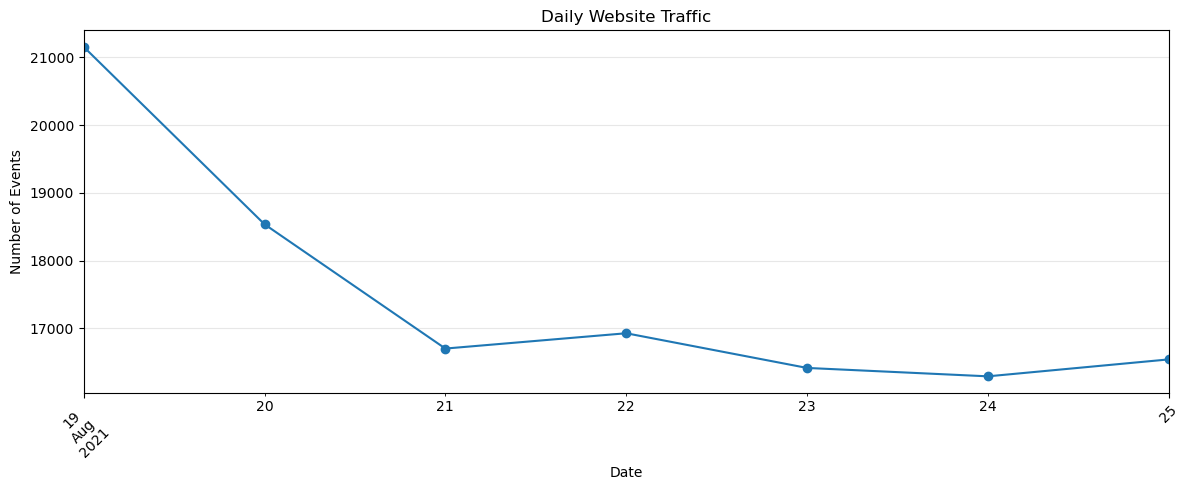

In [25]:
plt.figure(figsize=(12, 5))

daily_events.plot(kind='line', marker='o')

plt.title('Daily Website Traffic')
plt.xlabel('Date')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
daily_event = df.groupby(['date', 'event']).size().unstack(fill_value=0)

daily_event

event,click,pageview,preview
date,,,
2021-08-19,5860,13006,2290
2021-08-20,4999,11088,2449
2021-08-21,4279,9939,2483
2021-08-22,4421,9982,2524
2021-08-23,4314,9722,2379
2021-08-24,4231,9705,2355
2021-08-25,4395,9918,2228


<Figure size 1200x600 with 0 Axes>

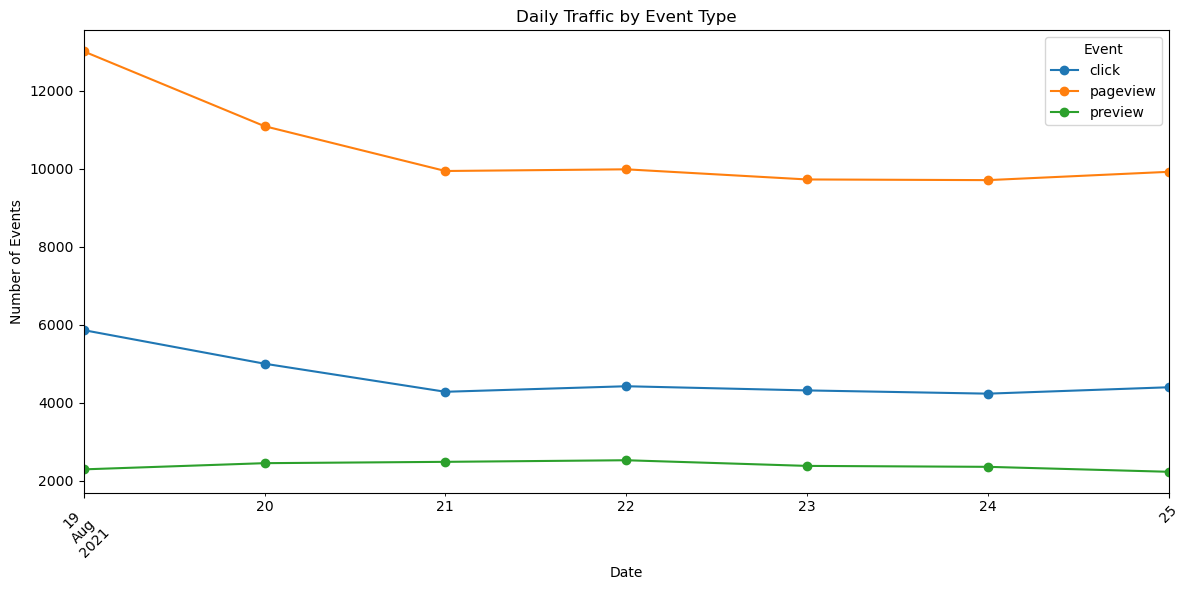

In [27]:
plt.figure(figsize=(12, 6))

daily_event.plot(kind='line', marker='o', figsize=(12, 6))

plt.title('Daily Traffic by Event Type')
plt.xlabel('Date')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.legend(title='Event')
plt.tight_layout()
plt.show()

In [28]:
top_countries = df['country'].value_counts().head(10)

top_countries

country
United States     28664
India             18689
France            10565
Saudi Arabia       7682
United Kingdom     5095
Germany            4017
Canada             2784
Pakistan           2633
Iraq               2444
Turkey             2399
Name: count, dtype: int64

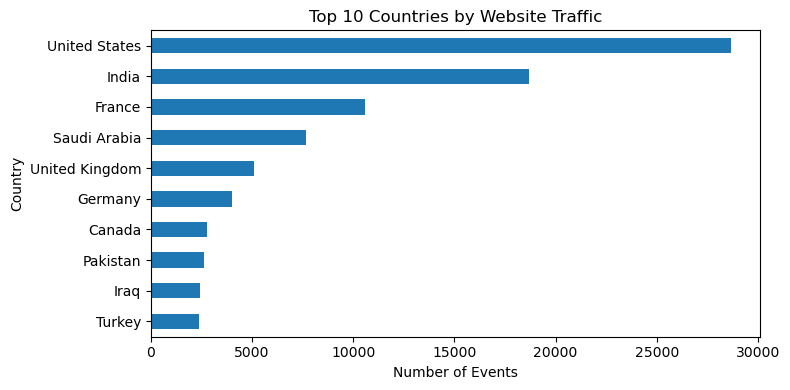

In [32]:
plt.figure(figsize=(8, 4))

top_countries.sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Website Traffic')
plt.xlabel('Number of Events')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [33]:
top_cities = df['city'].value_counts().head(10)

top_cities

city
Unknown        8797
Jeddah         2497
Riyadh         2232
Hyderabad      1088
Dammam         1002
Delhi           884
Jaipur          849
Lucknow         837
Kuwait City     816
Ahmedabad       808
Name: count, dtype: int64

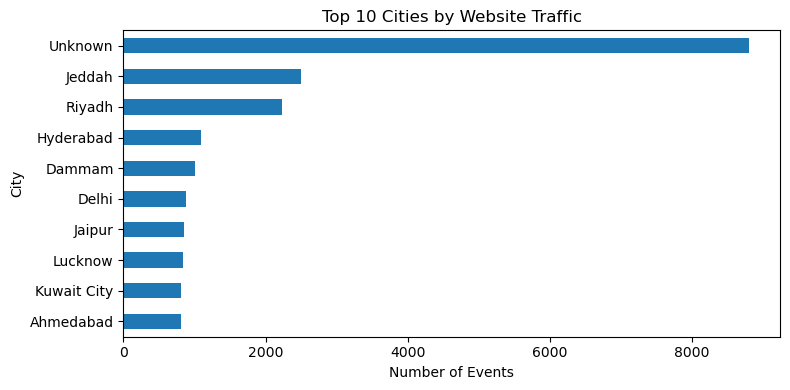

In [34]:
plt.figure(figsize=(8, 4))

top_cities.sort_values().plot(kind='barh')

plt.title('Top 10 Cities by Website Traffic')
plt.xlabel('Number of Events')
plt.ylabel('City')
plt.tight_layout()
plt.show()

In [8]:
top_artists = df['artist'].value_counts().head(10)

top_artists

artist
Tesher                                                          40841
Anne-Marie                                                      10650
Tundra Beats                                                     9751
Surf Mesa, Emilee                                                7533
DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna     5512
Reyanna Maria                                                    5437
Shawn Mendes, Tainy                                              5409
50 Cent, Olivia                                                  5367
Roddy Ricch                                                      5093
Olivia Rodrigo                                                   4115
Name: count, dtype: int64

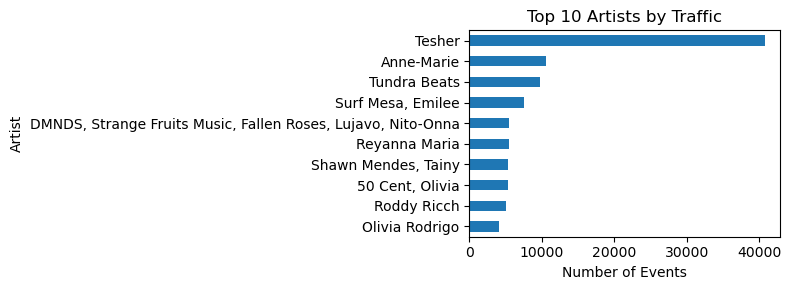

In [10]:
plt.figure(figsize=(8, 3))

top_artists.sort_values().plot(kind='barh')

plt.title('Top 10 Artists by Traffic')
plt.xlabel('Number of Events')
plt.ylabel('Artist')
plt.tight_layout()
plt.show()

In [11]:
top_tracks = df['track'].value_counts().head(10)

top_tracks

track
Jalebi Baby                              40841
Beautiful                                10658
Beautiful Day                             9751
ily (i love you baby) (feat. Emilee)      7533
So Pretty                                 5664
Calabria (feat. Lujavo & Nito-Onna)       5512
Summer of Love (Shawn Mendes & Tainy)     5409
Candy Shop                                5375
Late At Night                             5036
Build a Bitch                             3879
Name: count, dtype: int64

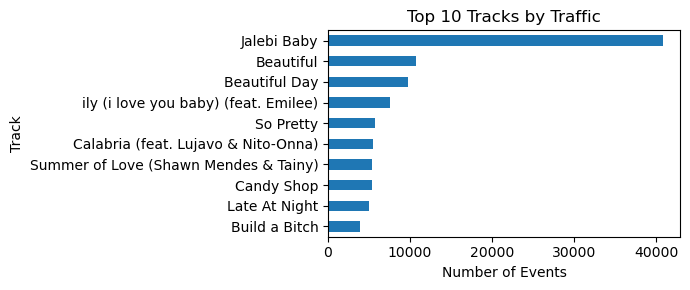

In [14]:
plt.figure(figsize=(7, 3))

top_tracks.sort_values().plot(kind='barh')

plt.title('Top 10 Tracks by Traffic')
plt.xlabel('Number of Events')
plt.ylabel('Track')
plt.tight_layout()
plt.show()

In [15]:
unique_links = df['linkid'].nunique()

print("Unique links:", unique_links)

Unique links: 3839


In [16]:
top_links = df['linkid'].value_counts().head(10)

top_links

linkid
2d896d31-97b6-4869-967b-1c5fb9cd4bb8    40841
522da5cc-8177-4140-97a7-a84fdb4caf1c    10314
e849515b-929d-44c8-a505-e7622f1827e9     9750
c2c876ab-b093-4750-9449-6b4913da6af3     6733
681d888a-59ce-4acb-b7c5-95dab0c063d9     5512
23199824-9cf5-4b98-942a-34965c3b0cc2     5437
97105aff-3e40-4c2e-bfeb-563b55e8f5dd     5367
d5317591-872a-487d-87cb-10a516643d5f     5352
a82e72d8-523f-43ab-9fd0-992605d54b4e     5036
a107c329-5d35-4c7d-8050-50bc69ce7dbc     3879
Name: count, dtype: int64

In [17]:
categorical_columns = [
    'event',
    'country',
    'city',
    'artist',
    'album',
    'track',
    'isrc',
    'linkid'
]

for col in categorical_columns:
    blank_count = (df[col].astype(str).str.strip() == '').sum()
    print(f"{col}: {blank_count} blank values")

event: 0 blank values
country: 0 blank values
city: 0 blank values
artist: 0 blank values
album: 0 blank values
track: 0 blank values
isrc: 0 blank values
linkid: 0 blank values


In [18]:
print("Final Dataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Final Dataset Shape:
(226278, 9)

Data Types:
event      object
date       object
country    object
city       object
artist     object
album      object
track      object
isrc       object
linkid     object
dtype: object

Missing Values:
event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64

Duplicate Rows:
103711


In [20]:
df.to_csv("traffic_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
